# 03_modeling_regresion.ipynb
Entrenamiento y evaluación de modelos de regresión.

In [5]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cwd = os.getcwd()
project_root = os.path.abspath(os.path.join(cwd, '..')) if os.path.basename(cwd) == 'notebooks' else cwd
data_path = os.path.join(project_root, 'data', 'processed', 'house_prices_clean.csv')
app_path = os.path.join(project_root, 'app')
reports_path = os.path.join(project_root, 'reports')

print('Project root:', project_root)
print('Loading', data_path)
df = pd.read_csv(data_path)

features = [
    'bhk_count', 'carpet_area_num', 'floor_number', 'total_floors',
    'floor_ratio', 'Bathroom', 'Balcony', 'furnishing_score',
    'has_parking', 'is_luxury', 'has_garden_view', 'has_society',
    'city_avg_price'
 ]
cat_cols = ['Transaction', 'Status', 'Ownership']

df_model = pd.get_dummies(df[features + cat_cols + ['amount_rupees']],
                           columns=cat_cols, drop_first=True)
df_model = df_model.dropna()

X = df_model.drop(columns=['amount_rupees'])
y = df_model['amount_rupees']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Project root: c:\Users\juang\OneDrive\Desktop\UABC\CIENCIA DE DATOS\PROYECTOFINAL_GARFIAS\house_price_project
Loading c:\Users\juang\OneDrive\Desktop\UABC\CIENCIA DE DATOS\PROYECTOFINAL_GARFIAS\house_price_project\data\processed\house_prices_clean.csv
Train shape: (124665, 19) Test shape: (31167, 19)


In [6]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
        'R2': r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.round(2)
display(results_df)

best_model = models['Random Forest']
joblib.dump(best_model, os.path.join(app_path, 'model_rf.pkl'))
joblib.dump(X.columns.tolist(), os.path.join(app_path, 'feature_names.pkl'))
print('Mejor modelo y nombres de features guardados en app/')

,MAE,RMSE,R2
Random Forest,736441.20,1808673.89,0.92
Ridge Regression,2993116.05,4022467.20,0.58


Mejor modelo y nombres de features guardados en app/


## Gráfico de residuos del mejor modelo

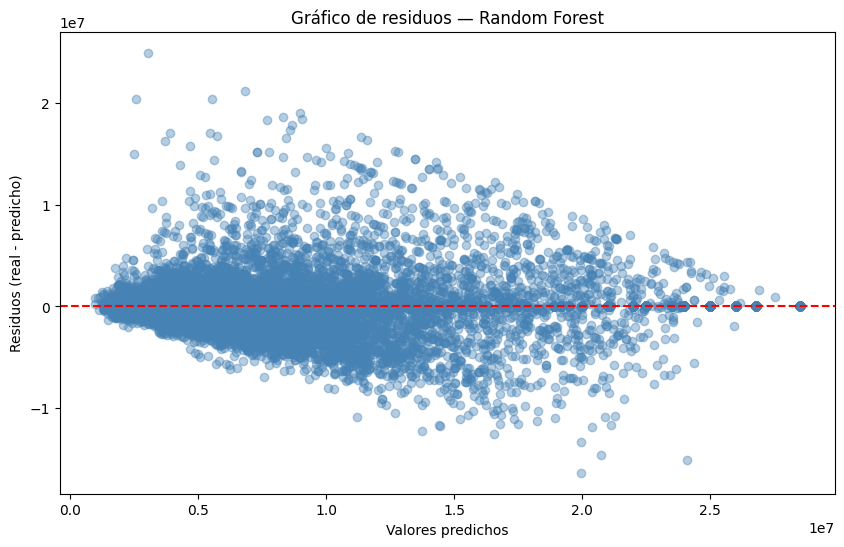

In [7]:
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.4, color='steelblue')
plt.axhline(0, linestyle='--', color='red')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos (real - predicho)')
plt.title('Gráfico de residuos — Random Forest')
plt.savefig(os.path.join(reports_path, 'figures', '06_residuos.png'), dpi=150, bbox_inches='tight')
plt.show()

## Importancia de features

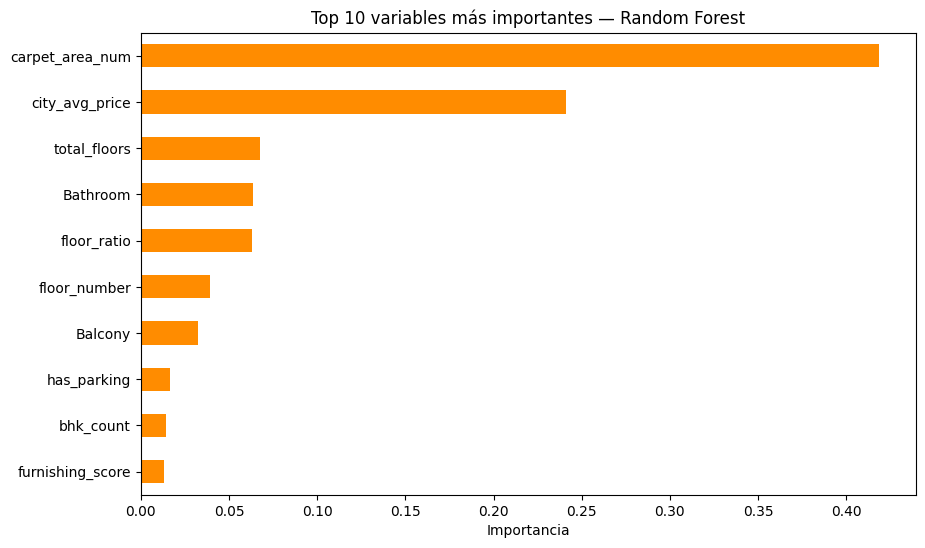

In [8]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=True).tail(10)
plt.figure(figsize=(10, 6))
top_importances.plot(kind='barh', color='darkorange')
plt.title('Top 10 variables más importantes — Random Forest')
plt.xlabel('Importancia')
plt.savefig(os.path.join(reports_path, 'figures', '07_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Curva de aprendizaje

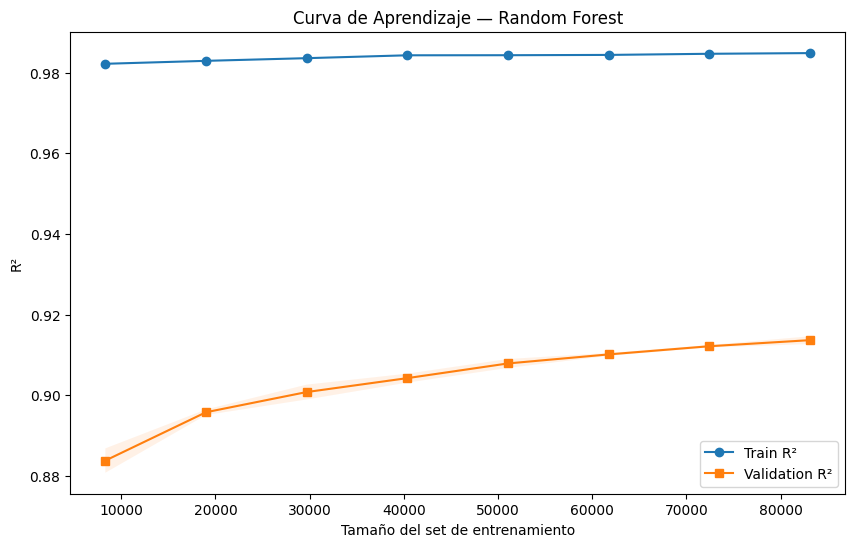

In [9]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42),
    X_train, y_train, cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
 )

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Train R²')
plt.plot(train_sizes, val_mean, marker='s', label='Validation R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.xlabel('Tamaño del set de entrenamiento')
plt.ylabel('R²')
plt.title('Curva de Aprendizaje — Random Forest')
plt.legend()
plt.savefig(os.path.join(reports_path, 'figures', '08_curva_aprendizaje.png'), dpi=150, bbox_inches='tight')
plt.show()